In [1]:
import pandas as pd
import seaborn as sns, matplotlib.pyplot as plt, numpy as np

csvs = [
    '1pct.csv',
    '10pct.csv',
    '25pct.csv',
    '50pct.csv',
]


mdf = pd.DataFrame()
for csv in csvs:
    df = pd.read_csv('data/' + csv)
    df['Training data percent'] = csv.split('.')[0].replace('pct', '%')
    mdf = pd.concat([mdf, df], ignore_index=True)

mdf

mdf['Percent loss from equivariance error'] = mdf['equivar_loss_term_3'] / (mdf['equivar_loss_term_3'] + mdf['equivar_loss_term_2'])

In [2]:
mdf.columns

Index(['epoch', 'iteration', 'equivar_loss_term_1', 'equivar_loss_term_2',
       'equivar_loss_term_3', 'equivar_loss_term_4', 'equivar_sanity_check',
       'standard_val_loss', 'loss_diff', 'grad_norm_equiv', 'grad_norm_pred',
       'grad_norm_ratio', 'Training data percent', 'modified pct',
       'Percent loss from equivariance error'],
      dtype='object')

In [3]:
from matplotlib import font_manager

font_dirs = ['/home/shenm19/arial-font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'

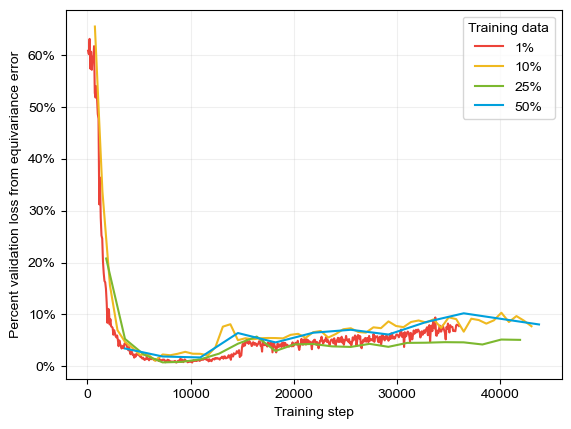

In [8]:
fig, ax = plt.subplots()
sns.lineplot(
    data = mdf,
    x = 'iteration',
    y = 'Percent loss from equivariance error',
    hue = 'Training data percent',
    palette = {
        '1%': '#ec4339',
        '10%': '#efb920',
        '25%': '#7cb82f',
        '50%': '#00a0dc',
    },
    errorbar = None,
    ax = ax,
)
plt.grid(alpha = 0.2)
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Training step')
plt.ylabel('Percent validation loss from equivariance error')
plt.legend(title = 'Training data')

plot_name = 'voxmol-vary-data'

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

import os
os.makedirs('pdfs', exist_ok=True)
os.makedirs('svgs', exist_ok=True)

plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.savefig('svgs/' + plot_name + '.svg', transparent = True)
plt.show()
plt.close()

### Loss curves

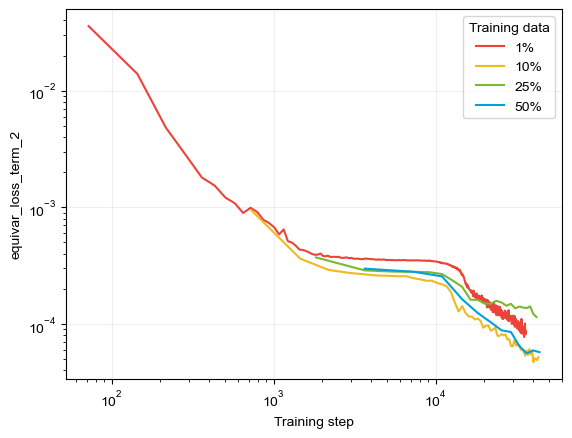

In [9]:
fig, ax = plt.subplots()
sns.lineplot(
    data = mdf,
    x = 'iteration',
    y = 'equivar_loss_term_2',
    hue = 'Training data percent',
    palette = {
        '1%': '#ec4339',
        '10%': '#efb920',
        '25%': '#7cb82f',
        '50%': '#00a0dc',
    },
    errorbar = None,
    ax = ax,
)
plt.grid(alpha = 0.2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Training step')
# plt.ylabel('Percent validation loss from equivariance error')
plt.legend(title = 'Training data')

plot_name = 'voxmol-vary-data'

import os
os.makedirs('pdfs', exist_ok=True)
os.makedirs('svgs', exist_ok=True)

# plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
# plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
# plt.savefig('svgs/' + plot_name + '.svg', transparent = True)
plt.show()
plt.close()

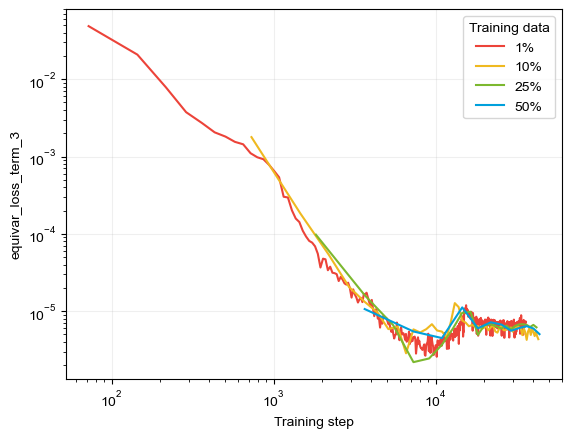

In [ ]:
fig, ax = plt.subplots()
sns.lineplot(
    data = mdf,
    x = 'iteration',
    y = 'equivar_loss_term_3',
    hue = 'Training data percent',
    palette = {
        '1%': '#ec4339',
        '10%': '#efb920',
        '25%': '#7cb82f',
        '50%': '#00a0dc',
    },
    errorbar = None,
    ax = ax,
)
plt.grid(alpha = 0.2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Training step')
# plt.ylabel('Percent validation loss from equivariance error')
plt.legend(title = 'Training data')

plot_name = 'voxmol-vary-data'

import os
os.makedirs('pdfs', exist_ok=True)
os.makedirs('svgs', exist_ok=True)

# plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
# plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
# plt.savefig('svgs/' + plot_name + '.svg', transparent = True)
plt.show()
plt.close()

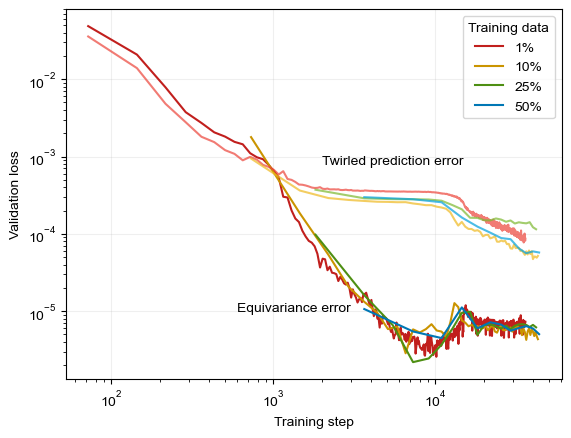

In [20]:
fig, ax = plt.subplots()
sns.lineplot(
    data = mdf,
    x = 'iteration',
    y = 'equivar_loss_term_3',
    hue = 'Training data percent',
    palette = {
        '1%': '#c11f1d',
        '10%': '#ca9400',
        '25%': '#4e8f13',
        '50%': '#0077b5',
    },
    errorbar = None,
    ax = ax,
)
sns.lineplot(
    data = mdf,
    x = 'iteration',
    y = 'equivar_loss_term_2',
    hue = 'Training data percent',
    palette = {
        '1%': '#ec4339',
        '10%': '#efb920',
        '25%': '#7cb82f',
        '50%': '#00a0dc',
    },
    alpha = 0.7,
    errorbar = None,
    ax = ax,
    legend = False,
)

plt.grid(alpha = 0.2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Training step')
plt.ylabel('Validation loss')
plt.legend(title = 'Training data')

plt.text(2000, 8e-4, 'Twirled prediction error')
plt.text(6e2, 1e-5, 'Equivariance error')

plot_name = 'voxmol-loss-curves'

import os
os.makedirs('pdfs', exist_ok=True)
os.makedirs('svgs', exist_ok=True)

plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.savefig('svgs/' + plot_name + '.svg', transparent = True)
plt.show()
plt.close()